# Assignment #2
**Course:** Advanced AI & Emergent Technologies

## 1. Environment Setup & CPU Optimization
We configure TensorFlow to utilize the full CPU and check for **Intel Arc GPU** acceleration.


In [2]:
import os
import glob
import concurrent.futures
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Hardware Acceleration Check
try:
    import importlib
    if importlib.util.find_spec("intel_extension_for_tensorflow") is None:
        raise ImportError
    itex = importlib.import_module("intel_extension_for_tensorflow")
    print('Success: Intel Arc GPU acceleration active.')
except ImportError:
    print('Note: Intel Extension not found. Running on high-performance CPU (oneDNN).')


# Optimize Threading for CPU
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

print(f'TensorFlow configured for maximum CPU threads: {os.cpu_count()}')


Note: Intel Extension not found. Running on high-performance CPU (oneDNN).
TensorFlow configured for maximum CPU threads: 22


## 2. Parallel Data Loading (Full Dataset)
Utilizing `ThreadPoolExecutor` to load multiple CSV files simultaneously from the 'archive' folder.


In [3]:
def load_single_csv(filename):
    df = pd.read_csv(filename, low_memory=False)
    df.columns = df.columns.str.strip()
    return df

def load_full_dataset_parallel(directory_path):
    all_files = glob.glob(os.path.join(directory_path, '*.csv'))
    print(f'Detected {len(all_files)} files. Utilizing parallel I/O...')
    with concurrent.futures.ThreadPoolExecutor() as executor:
        df_list = list(executor.map(load_single_csv, all_files))
    return pd.concat(df_list, axis=0, ignore_index=True)

def preprocess_data_optimized(df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    # Downsample for 16GB RAM Safety
    if len(df) > 1000000:
        print('Downsampling to 1,000,000 rows for memory stability...')
        df = df.sample(n=1000000, random_state=42).sort_index()
    le = LabelEncoder()
    df['Label'] = le.fit_transform(df['Label'])
    features = df.drop('Label', axis=1).select_dtypes(include=[np.number])
    labels = df['Label'].values
    scaler = MinMaxScaler()
    features_scaled = scaler.fit_transform(features)
    #remove classes with fewer than 2 samples
    class_counts = df['Label'].value_counts()
    to_keep = class_counts[class_counts >= 2].index
    df = df[df['Label'].isin(to_keep)]
    return features_scaled, labels, le


## 3. Modeling & Evaluation (Unencoded Labels)
Defining architectures and evaluation functions that map indices back to the original attack names.


In [4]:
def evaluate_model(model, X_test, y_test, name, encoder, is_dl=True):
    if is_dl: y_pred = np.argmax(model.predict(X_test), axis=1)
    else: y_pred = model.predict(X_test)
    real_labels = encoder.classes_
    present_labels = np.unique(np.concatenate((y_test, y_pred)))
    target_names = [real_labels[i] for i in present_labels]
    print(f'\n=== {name} Evaluation ===')
    print(classification_report(y_test, y_pred, target_names=target_names))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(f'cm_{name.lower().replace(" ", "_")}.png'); plt.show()

## 4. Main Execution Pipeline
Processing the entire archive and training the model.


Detected 8 files. Utilizing parallel I/O...
Downsampling to 1,000,000 rows for memory stability...

=== Random Forest Baseline Evaluation ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    160519
                       Bot       0.83      0.47      0.60       133
                      DDoS       1.00      1.00      1.00      9042
             DoS GoldenEye       0.99      1.00      1.00       743
                  DoS Hulk       1.00      1.00      1.00     16363
          DoS Slowhttptest       0.99      0.99      0.99       392
             DoS slowloris       1.00      0.99      1.00       418
               FTP-Patator       1.00      1.00      1.00       555
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       1.00      1.00      1.00         2
                  PortScan       0.99      1.00      1.00     11263
               SSH-Patator       1.00    

c:\Users\awag9\Desktop\Advanced AI Assignment 1 & 2\assignment_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\awag9\Desktop\Advanced AI Assignment 1 & 2\assignment_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\awag9\Desktop\Advanced AI Assignment 1 & 2\assignment_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

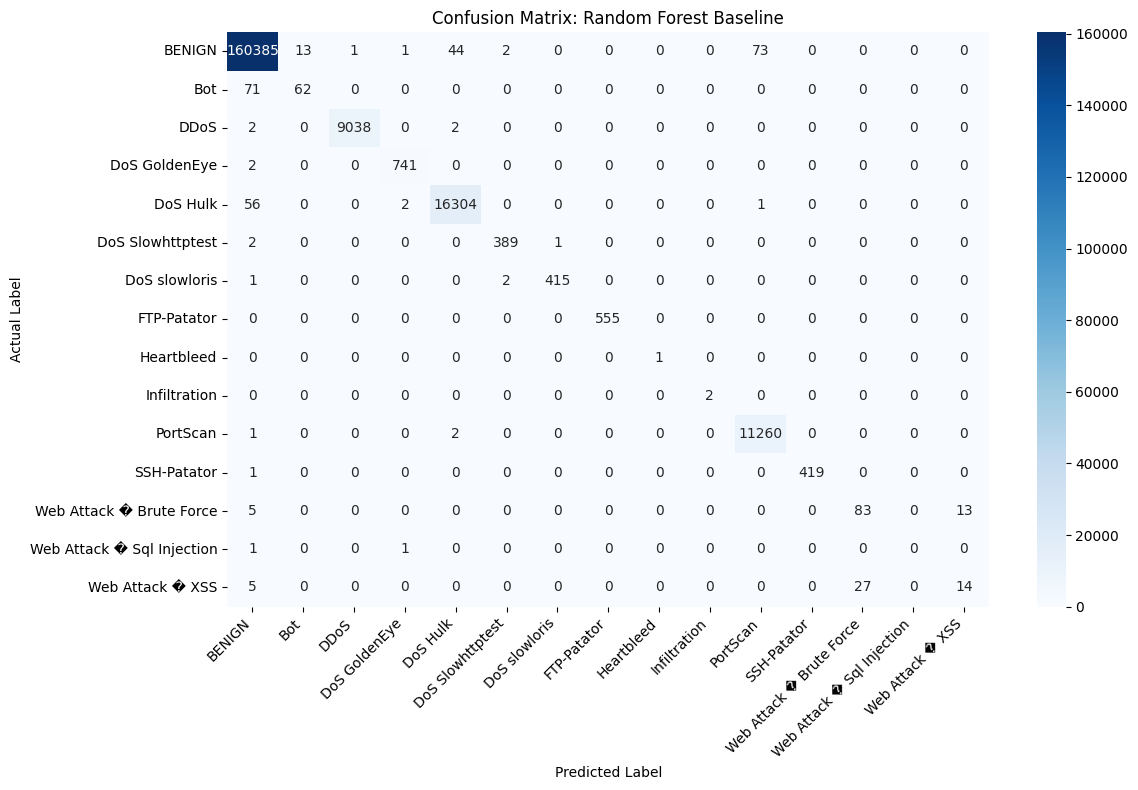

In [5]:
# 1. Load & Preprocess
raw_df = load_full_dataset_parallel('archive')
X_flat, y_flat, encoder = preprocess_data_optimized(raw_df)
num_classes = len(encoder.classes_)

# 2. Random Forest Baseline (n_jobs=-1 for all CPU cores)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_flat, y_flat, test_size=0.2, random_state=42, stratify=y_flat)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(X_train_f, y_train_f)
evaluate_model(rf, X_test_f, y_test_f, 'Random Forest Baseline', encoder, is_dl=False)


In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer for your Random Forest
# TreeExplainer is specifically optimized for ensemble tree models
explainer = shap.TreeExplainer(rf)

# 2. Calculate SHAP values for the entire test set (X_test_f)
print("Calculating SHAP values for the full test set...")
shap_values = explainer.shap_values(X_test_f)

# 3. Summary Plot: Identifying the most influential features globally
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_f, 
    feature_names=features.columns, 
    class_names=encoder.classes_,
    plot_type="bar" # Bar plot is best for a high-level "Importance" overview
)
plt.title("Global Feature Importance (Full Test Set)")
plt.savefig("shap_global_importance_full.png")
plt.show()

c:\Users\awag9\Desktop\Advanced AI Assignment 1 & 2\assignment_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 3. Summary Plot: Identifying the most influential features globally
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_f, 
    feature_names=features.columns, 
    class_names=encoder.classes_,
    plot_type="bar" # Bar plot is best for a high-level "Importance" overview
)
plt.title("Global Feature Importance (Full Test Set)")
plt.savefig("shap_global_importance_full.png")
plt.show()